# GasOpt — real Ethereum data

**Phase 2: provenance, quality and whole-day scenario construction.**

Audience: MSc optimization students. Prerequisites: the Phase 1 model, installed
development dependencies and local Dune extracts prepared according to the README.
All price analysis is in gwei/gas; all optimization cost analysis is in ETH.
This notebook never downloads data. If real data is missing, it explicitly skips
data-dependent cells. Synthetic test fixtures are never displayed as Ethereum.

## A. Dataset provenance

Source: Dune Analytics `gas.fees`, Ethereum Mainnet only. The slot SQL aggregates
transactions into UTC two-hour bins; the workload SQL samples actual gas usage
from TRAIN only. The exact SQL and extract hashes are recorded in local metadata.

The [schema documentation](https://docs.dune.com/data-catalog/curated/gas-fees/fees)
labels `gas_price` as gwei, whereas the official
[Ethereum SQL implementation](https://github.com/duneanalytics/spellbook/blob/main/dbt_subprojects/hourly_spellbook/models/_sector/gas/fees/ethereum/gas_ethereum_fees.sql)
appears to retain raw wei. Our configurable conversion is independently audited
against `gas_price_gwei * gas_used * 1e-9 = tx_fee - blob_fee`. Source-unit errors
stop preparation. Fee fields in USD are retained only for provenance.

The execution-price proxy includes base and priority fees, not base fee alone.
Blob charges are separate and excluded from the execution-gas identity.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

from gasopt.config import load_config
from gasopt.data.empirical import build_workload, daily_scenarios, split_daily_slots
from gasopt.empirical_study import load_processed, fit_strategies, study_from_frames, run_study
from gasopt.baselines import immediate_schedule
from gasopt.evaluation.metrics import mean_prices_gwei, scenario_costs_eth, weighted_var_cvar
from gasopt.evaluation.out_of_sample import cost_summary, evaluate_schedules

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
config = load_config(ROOT / 'config/empirical.toml')
PROCESSED = ROOT / 'data/processed'
OUTPUT = ROOT / 'outputs/empirical'
DATA_LABEL = 'EMPIRICAL ETHEREUM'
DATA_AVAILABLE = (PROCESSED / 'metadata.json').exists()
if DATA_AVAILABLE:
    slots, observations, metadata = load_processed(PROCESSED, config)
    train_slots, test_slots = split_daily_slots(slots, config)
    display(Markdown('**Verified local empirical data loaded. All analysis below is offline.**'))
else:
    display(Markdown('**EMPIRICAL RESULTS PENDING.** No verified Dune extract is present. '
                     'Run the extraction/import and preparation steps in `docs/phase2.md`. '
                     'Data-dependent cells below are explicitly skipped; no synthetic substitute is used.'))
pd.set_option('display.float_format', lambda value: f'{value:.9f}')
display(pd.Series(config.to_dict(), name='Prespecified configuration').to_frame())

**Verified local empirical data loaded. All analysis below is offline.**

,Prespecified configuration
train_start,2025-01-01
train_end,2025-12-31
test_start,2026-01-01
test_end,2026-03-31
alpha,0.950000000
lambda_grid,"(0.0, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2...."
min_train_tail_count,10.000000000
max_missing_day_fraction,0.050000000
transaction_count,30
sample_seed,20260923


In [2]:
if DATA_AVAILABLE:
    provenance_rows = []
    for kind, source in metadata['provenance'].items():
        provenance_rows.append({key: source[key] for key in
            ('extract_kind', 'source', 'blockchain', 'extracted_at_utc', 'source_reference', 'sha256')})
    display(pd.DataFrame(provenance_rows))
    display(Markdown('**Exact executed slot query:**'))
    print(metadata['provenance']['slots']['sql'])

,extract_kind,source,blockchain,extracted_at_utc,source_reference,sha256
0,slots,Dune Analytics gas.fees,ethereum,2026-09-24T12:49:58.994912+00:00,01M39QBXRCQGR7AAMGG56JB2GC,25aa5f7e0590b393d082f432b4393886881a08862d8226...
1,workload,Dune Analytics gas.fees,ethereum,2026-09-24T12:51:13.823907+00:00,01M39QFP26T5K5X07E6YW2926F,d5b388fe6f404fd042e1b6a8c9647336443e7d3888ea0c...


**Exact executed slot query:**

-- DuneSQL. Render with python -m gasopt.data.dune render --config ...
-- Inclusive fixed UTC dates. Approximate quantiles use Dune's approx_percentile.
-- Preserve full trajectories; no random or independent slot sampling.
-- gas_price raw units MUST pass the fee-identity audit before use.
WITH source AS (
    SELECT block_date,
           date_trunc('day', block_time) + INTERVAL '2' HOUR *
               CAST(floor(hour(block_time) / 2.0) AS BIGINT) AS slot_start,
           CAST(floor(hour(block_time) / 2.0) AS INTEGER) + 1 AS slot,
           CAST(gas_price AS DOUBLE) AS gas_price_raw,
           CAST(gas_price AS DOUBLE) * 1e-9 AS gas_price_gwei,
           gas_used, tx_fee, tx_fee_usd,
           tx_fee - coalesce(element_at(tx_fee_breakdown, 'blob_fee'), 0) AS execution_fee_eth
    FROM gas.fees
    WHERE blockchain = 'ethereum'
      AND block_month >= date_trunc('month', DATE '2025-01-01')
      AND block_date BETWEEN DATE '2025-01-01' AND DATE '2026-03-31'
      AND block_tim

## B. Raw and processed date ranges

Dates below distinguish the raw aggregate extract, retained complete scenarios,
and gas-use sample. A local aggregate row represents a slot, not one transaction.
The sum of `transaction_count` is the underlying source transaction count.

In [3]:
if DATA_AVAILABLE:
    quality = metadata['quality']
    display(pd.DataFrame([
        {'dataset': 'raw slot extract', 'first_date': quality['raw_date_min'], 'last_date': quality['raw_date_max'],
         'rows': quality['raw_aggregate_rows']},
        {'dataset': 'retained slots', 'first_date': slots.day.min(), 'last_date': slots.day.max(), 'rows': len(slots)},
        {'dataset': 'TRAIN gas-use sample', 'first_date': observations.day.min(), 'last_date': observations.day.max(),
         'rows': len(observations)}
    ]))
    print('Underlying transaction observations:', quality['raw_transaction_observations'])
    print('Invalid/nonpositive source rows excluded:', quality['excluded_transaction_observations'])

,dataset,first_date,last_date,rows
0,raw slot extract,2025-01-01,2026-03-31,5460
1,retained slots,2025-01-01 00:00:00+00:00,2026-03-31 00:00:00+00:00,5460
2,TRAIN gas-use sample,2025-01-01,2025-12-31,23360


Underlying transaction observations: 724380678
Invalid/nonpositive source rows excluded: 0


## C. Data-quality checks

Each retained scenario must contain exactly 12 unique slots, positive finite
prices and gas usage, explicit UTC timestamps, and no missing prices.
Incomplete days are reported and removed without interpolation. More than the
prespecified missing-day fraction in either split stops preparation.

Unit audit: relative fee-identity errors at both the median and p95 must be at
most $10^{-6}$, with at least 99% fee coverage. The metadata reports every removed
or entirely absent day. Duplicate day/slot rows are rejected rather than averaged.

In [4]:
if DATA_AVAILABLE:
    display(pd.Series(metadata['quality'], name='Quality report').to_frame())
    assert slots.groupby('day').size().eq(12).all()
    assert not slots.duplicated(['day', 'slot']).any()
    assert slots.median_gas_price_gwei.gt(0).all()
    assert not slots.median_gas_price_gwei.isna().any()
    assert str(slots.slot_start_utc.dt.tz) == 'UTC'
    display(slots[['unit_check_median_relative_error', 'unit_check_p95_relative_error']].describe())

,Quality report
raw_aggregate_rows,5460
raw_transaction_observations,724380678
valid_transaction_observations,724380678
excluded_transaction_observations,0
raw_date_min,2025-01-01
raw_date_max,2026-03-31
retained_aggregate_rows,5460
retained_daily_scenarios,455
timezone,UTC
duplicate_day_slots,0


,unit_check_median_relative_error,unit_check_p95_relative_error
count,5460.000000000,5460.000000000
mean,0.000000000,0.000000000
std,0.000000000,0.000000000
min,0.000000000,0.000000000
25%,0.000000000,0.000000000
50%,0.000000000,0.000000000
75%,0.000000000,0.000000000
max,0.000000000,0.000000000


## D. Distribution of gas prices

The decision price $p_{ts}$ is the transaction-level median in slot $t$ of day $s$.
The tables summarize the distribution of **slot medians**, not all transaction
prices. Dune uses approximate percentiles within each slot. TRAIN and TEST
summaries are explicitly separated; TEST descriptions do not alter model inputs.

,TRAIN slot medians,TEST slot medians
count,4380.000000000,1080.000000000
mean,2.368056894,0.198468953
std,5.670955449,0.565151680
min,0.026310721,0.031184175
25%,0.383350888,0.049953397
50%,0.961417686,0.075573909
75%,2.108032897,0.158797455
95%,9.011970536,0.637723585
max,155.175537909,12.099194950


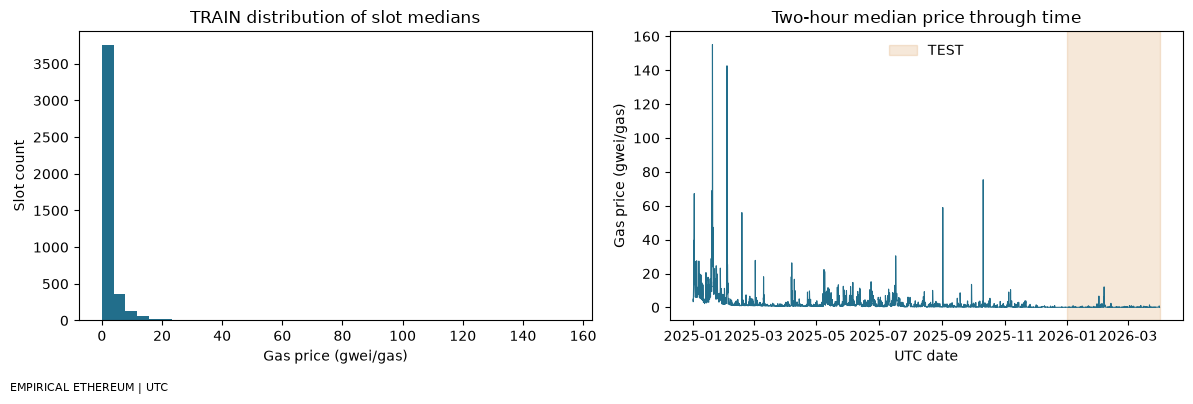

In [5]:
if DATA_AVAILABLE:
    display(pd.DataFrame({label: frame.median_gas_price_gwei.describe(percentiles=[.25, .5, .75, .95])
        for label, frame in [('TRAIN slot medians', train_slots), ('TEST slot medians', test_slots)]}))
    EXPLORATION = OUTPUT / 'exploration'
    EXPLORATION.mkdir(parents=True, exist_ok=True)
    def save_exploration(fig, name):
        fig.text(.01, .01, DATA_LABEL + ' | UTC', fontsize=8)
        fig.tight_layout(rect=(0, .04, 1, 1))
        for extension in ('png', 'pdf'):
            fig.savefig(EXPLORATION / f'{name}.{extension}', dpi=220, bbox_inches='tight')
        display(fig)
        plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(train_slots.median_gas_price_gwei, bins=40, color='#226e8b')
    axes[0].set(title='TRAIN distribution of slot medians', xlabel='Gas price (gwei/gas)', ylabel='Slot count')
    axes[1].plot(slots.slot_start_utc, slots.median_gas_price_gwei, lw=.8, color='#226e8b')
    axes[1].axvspan(pd.Timestamp(config.test_start, tz='UTC'), pd.Timestamp(config.test_end, tz='UTC') + pd.Timedelta(days=1),
                   alpha=.2, color='#d58c43', label='TEST')
    axes[1].set(title='Two-hour median price through time', ylabel='Gas price (gwei/gas)', xlabel='UTC date')
    axes[1].legend(frameon=False)
    save_exploration(fig, 'price_distribution_and_time')

## E. Median gas price by time of day

The profile below takes the median **across days of within-slot medians**.
This descriptive profile is not the deterministic objective's price vector:
the objective uses the **mean across TRAIN scenarios of slot medians**.

,TRAIN,TEST (descriptive)
slot,,
1,0.726465531,0.055757450
2,0.727193610,0.052225971
3,0.670090577,0.046019237
4,0.769512816,0.052152557
5,0.883359258,0.070907951
6,0.963211964,0.079244458
7,1.282040937,0.125018711
8,2.085664046,0.316025600
9,1.775307206,0.252655102


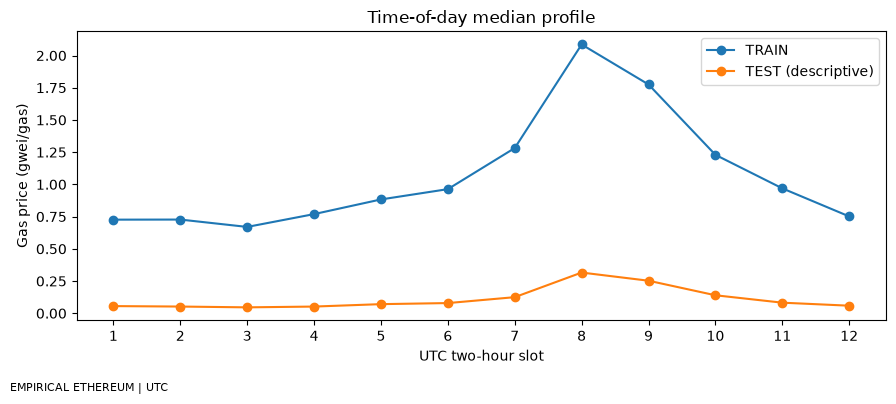

In [6]:
if DATA_AVAILABLE:
    profiles = pd.DataFrame({label: frame.groupby('slot').median_gas_price_gwei.median()
        for label, frame in [('TRAIN', train_slots), ('TEST (descriptive)', test_slots)]})
    display(profiles)
    fig, ax = plt.subplots(figsize=(9, 4))
    profiles.plot(ax=ax, marker='o')
    ax.set(title='Time-of-day median profile', xlabel='UTC two-hour slot', ylabel='Gas price (gwei/gas)', xticks=range(1, 13))
    save_exploration(fig, 'time_of_day_profile')

## F. Day-by-slot heatmap

Each row is one intact day. Vertical structure reveals daily regimes and
within-day co-movement retained by the scenario model. Sampling slots
independently would destroy this joint structure.

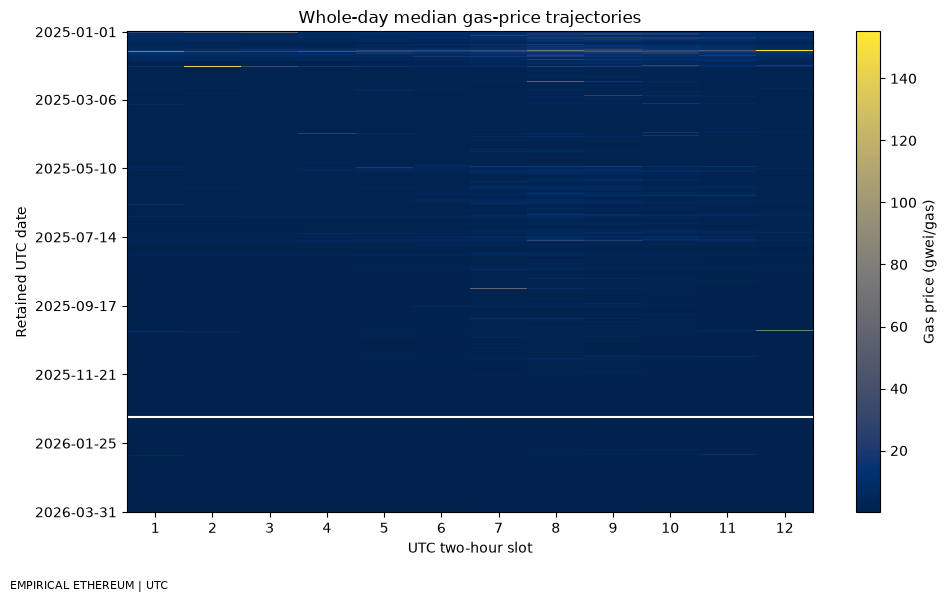

In [7]:
if DATA_AVAILABLE:
    wide = slots.pivot(index='day', columns='slot', values='median_gas_price_gwei')
    fig, ax = plt.subplots(figsize=(10, 6))
    image = ax.imshow(wide.to_numpy(), aspect='auto', cmap='cividis', interpolation='nearest')
    indices = np.unique(np.linspace(0, len(wide) - 1, min(8, len(wide))).astype(int))
    ax.set(xticks=range(12), xticklabels=range(1, 13), yticks=indices,
           yticklabels=[pd.Timestamp(wide.index[i]).strftime('%Y-%m-%d') for i in indices],
           xlabel='UTC two-hour slot', ylabel='Retained UTC date', title='Whole-day median gas-price trajectories')
    ax.axhline(np.searchsorted(wide.index, pd.Timestamp(config.test_start, tz='UTC')) - .5, color='white')
    fig.colorbar(image, ax=ax, label='Gas price (gwei/gas)')
    save_exploration(fig, 'daily_trajectory_heatmap')

## G. Gas-used distribution and the fixed treasury workload

The workload sample contains actual TRAIN `gas_used` observations with source
hash/time. The SQL applies explicit gas bounds and a reproducible hash-based,
day-stratified subsample. Locally, trim at observed 1st/99th percentiles and
select 30 representative observed ranks. No selected gas value is interpolated.

URGENT, STANDARD and FLEXIBLE windows are **business assumptions**. The seeded
permutation separates gas-size ordering from the deterministic timing-class
cycle. These timing labels cannot be inferred from blockchain observations.

,Construction audit
raw_sample_rows,23360
bounded_rows,23360
trimmed_rows,23126
trim_lower_gas,21000
trim_upper_gas,595254
transaction_count,30
training_days_in_sample,365
seed,20260923
missing_training_days,[]
method,nearest observed ranks of trimmed TRAIN sample...


,TRAIN observed gas,Selected workload gas
count,23360.000000000,30.000000000
mean,82343.949186644,85105.200000000
std,109866.550471739,117868.387056657
min,21000.000000000,21000.000000000
25%,21000.000000000,21000.000000000
50%,44206.000000000,43234.500000000
75%,95517.250000000,89271.250000000
95%,280205.650000000,262687.700000000
max,997824.000000000,595254.000000000


,transaction_id,gas_used,release_slot,deadline_slot,priority_class,source_tx_hash,source_block_time_utc,gas_usage_origin,timing_origin
0,treasury_01,21000,1,2,URGENT,0x0007ada267939d281a28b47ac0836e6265d4883fe219...,2025-04-20 05:33:11+00:00,observed training transaction,explicit business assumption
1,treasury_02,21000,1,4,STANDARD,0x0002ec759950ef6e84daecfa3ca296884682e4169c1b...,2025-12-30 03:14:11+00:00,observed training transaction,explicit business assumption
2,treasury_03,296588,1,8,FLEXIBLE,0x000403a7a5b519ef03549ffddb6d3b63eb1b67c74cd8...,2025-12-06 11:49:23+00:00,observed training transaction,explicit business assumption
3,treasury_04,46109,2,3,URGENT,0x000bc16ed9069c9308d9d5ab04dadba2b56f6ed5493b...,2025-10-13 12:42:35+00:00,observed training transaction,explicit business assumption
4,treasury_05,51957,2,5,STANDARD,0x000a41b12a65087e0ada80452e822a148c13e5182461...,2025-02-10 20:58:23+00:00,observed training transaction,explicit business assumption
5,treasury_06,21000,2,9,FLEXIBLE,0x0005c38ed75f5016f50b269dfd86f32e17f560abd265...,2025-07-02 18:27:47+00:00,observed training transaction,explicit business assumption
6,treasury_07,96383,3,4,URGENT,0x000bff6c5ea6422097e40f1aee8793ece7ffc207f0d7...,2025-08-10 00:42:47+00:00,observed training transaction,explicit business assumption
7,treasury_08,41309,3,6,STANDARD,0x00055ef5551d06ebd4e208554245d80c079e3f7f9745...,2025-08-19 12:57:23+00:00,observed training transaction,explicit business assumption
8,treasury_09,221254,3,10,FLEXIBLE,0x0001c5c87e5f13ff7d6e36901ff11312c47c03bf7f99...,2025-10-27 13:45:11+00:00,observed training transaction,explicit business assumption
9,treasury_10,21000,4,5,URGENT,0x0004578ae82c92ed5199f0726191847cecb2b5aec022...,2025-03-15 18:08:35+00:00,observed training transaction,explicit business assumption


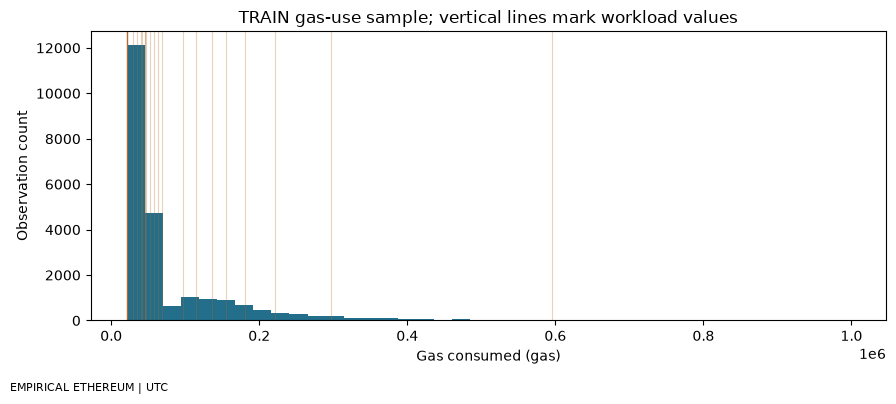

In [8]:
if DATA_AVAILABLE:
    transactions, workload, construction = build_workload(observations, config)
    display(pd.Series(construction, name='Construction audit').to_frame())
    display(pd.DataFrame({'TRAIN observed gas': observations.gas_used.describe(percentiles=[.25, .5, .75, .95]),
                          'Selected workload gas': workload.gas_used.describe(percentiles=[.25, .5, .75, .95])}))
    display(workload)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(observations.gas_used, bins=40, color='#226e8b')
    for value in workload.gas_used:
        ax.axvline(value, color='#b46a27', lw=.8, alpha=.3)
    ax.set(title='TRAIN gas-use sample; vertical lines mark workload values', xlabel='Gas consumed (gas)', ylabel='Observation count')
    save_exploration(fig, 'gas_used_sample')

## H. Chronological TRAIN/TEST split

The split is fixed before optimization. All TRAIN dates precede every TEST date;
there is no overlap. No TEST gas-use row can enter the workload function.
Incomplete-day rules are deterministic and prespecified, not selected for better
out-of-sample performance. No lambda is chosen by inspecting TEST costs.

In [9]:
if DATA_AVAILABLE:
    assert train_slots.day.max() < test_slots.day.min()
    assert set(train_slots.day).isdisjoint(set(test_slots.day))
    display(pd.DataFrame([{'split': label, 'first_day': frame.day.min(), 'last_day': frame.day.max(),
        'retained_days': frame.day.nunique(), 'tail_scenario_equivalents': (1-config.alpha)*frame.day.nunique()}
        for label, frame in [('TRAIN', train_slots), ('TEST', test_slots)]]))

,split,first_day,last_day,retained_days,tail_scenario_equivalents
0,TRAIN,2025-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,365,18.250000000
1,TEST,2026-01-01 00:00:00+00:00,2026-03-31 00:00:00+00:00,90,4.500000000


## I. Empirical scenario construction

$$p_s=(p_{1s},\ldots,p_{12s}),\qquad
p_{ts}=\operatorname{median}(\text{observed prices in day }s\text{, slot }t),\qquad q_s=1/S.$$

Each retained TRAIN day contributes one complete scenario. In the optimization,
$g_i$ is fixed across scenarios, while the daily price trajectory changes.
The following cell constructs scenarios using **only TRAIN**.

In [10]:
if DATA_AVAILABLE:
    train_scenarios = daily_scenarios(train_slots)
    assert all(len(s.prices_gwei) == 12 for s in train_scenarios)
    assert np.isclose(sum(s.probability for s in train_scenarios), 1)
    display(pd.DataFrame([s.prices_gwei for s in train_scenarios[:5]],
        index=[s.id for s in train_scenarios[:5]], columns=range(1, 13)))
    print(f'TRAIN scenarios: {len(train_scenarios)}; tail equivalents: {(1-config.alpha)*len(train_scenarios):.2f}')

,1,2,3,4,5,6,7,8,9,10,11,12
2025-01-01,4.814227874,3.335457169,3.382269054,4.249930030,6.069445604,8.870722500,11.753029031,36.109228778,29.051619812,29.877098440,39.596267730,29.310742345
2025-01-02,34.768790096,52.307160503,67.162070968,14.523485731,13.455383420,14.086546660,13.830514351,15.496979686,14.555207932,12.402280068,10.717866689,9.105485967
2025-01-03,8.778111600,8.018780126,6.019410561,6.492597383,9.026739810,8.680690625,11.422718705,18.694454172,27.162426145,21.454039638,14.063508989,9.598925418
2025-01-04,8.456275783,6.251190830,5.928470629,6.213582552,7.026590159,7.155082750,27.506413728,16.623795836,11.339798441,8.383691039,7.736971895,7.039985264
2025-01-05,6.663281913,6.217267976,6.279705321,6.147914481,6.050714250,6.308420646,10.080460557,11.892333511,10.358875294,8.903285832,9.234704329,9.567359276


TRAIN scenarios: 365; tail equivalents: 18.25


The next notebook derives the optimization problem and evaluates frozen schedules.
Median proxies do not guarantee inclusion prices. Day-stratified workload sampling,
incomplete-day removal, serial dependence and regime changes limit interpretation.
With only 90 TEST days, a 95% tail contains 4.5 scenario equivalents even when
coverage is complete. No statistical significance is claimed.